# 08 - Model Comparison and Calibration

## Credit Risk Modelling Using Logistic Regression

This notebook compares the Notebook 04 baseline, Notebook 06 advanced logistic model, Notebook 07 WoE scorecard, Random Forest, and Gradient Boosting. It uses the same seed 47 training and holdout split.

All transforms, model fitting, cross-validation, and calibrator fitting use training data only. The holdout is used once for final evaluation after the champion and calibration method have been selected from cross-validated training predictions.


## 1. Common validation protocol

The five candidates use the same target, eight engineered predictors, and stratified five-fold training cross-validation. Baseline, advanced, and WoE transformations are refit inside each fold. Tree model settings are fixed in advance and are not tuned against the holdout.

Out-of-fold (OOF) predictions support model and calibration-method selection. The final holdout is scored only after those choices are locked. The saved Notebook 04, 06, and 07 packages provide the corresponding fitted logistic candidates; tree candidates are fit on the complete training partition after cross-validation.


In [1]:
import os
import sys
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import roc_auc_score

sys.path.insert(0, "../src")
from model import prepare_data, split_data, predict_pd as base_pred
from advanced_model import predict_model, short_frame
from scorecard import score_rows
from evaluation import discrimination_metrics, calibration_table
from model_comparison import (
    MODEL_IDS, cross_preds, fit_tree, fit_cal, apply_cal, cross_cal,
    auc_ci, auc_diff_ci, predict_candidate,
)

clean = pd.read_csv("../data/processed/cleaned_data.csv")
feat, target = prepare_data(clean)
with open("../models/logistic_regression.pkl", "rb") as model_file:
    base_pack = pickle.load(model_file)
with open("../models/advanced_pd_model.pkl", "rb") as model_file:
    adv_pack = pickle.load(model_file)
with open("../models/scorecard_model.pkl", "rb") as model_file:
    score_pack = pickle.load(model_file)

train_feat, hold_feat, train_y, hold_y = split_data(
    feat, target, base_pack["seed"]
)
SEED = base_pack["seed"]
print(f"Seed: {SEED}")
print(f"Training borrowers: {len(train_y):,}")
print(f"Holdout borrowers: {len(hold_y):,}")
print(f"Training bad rate: {train_y.mean():.4%}")
print(f"Holdout bad rate: {hold_y.mean():.4%}")


Seed: 47
Training borrowers: 101,893
Holdout borrowers: 43,669
Training bad rate: 6.7541%
Holdout bad rate: 6.7531%


## 2. Training-only cross-validation

Each row receives an OOF prediction from a model that did not fit that row. Fold-specific scaling, nonlinear terms, scorecard bins, and WoE values are learned from each fold's training portion. This gives comparable training-only estimates for discrimination and probability error.


In [2]:
oof = cross_preds(train_feat, train_y, seed=SEED, n_splits=5)
print("OOF predictions complete:", oof["fold"].notna().all())
print(oof["fold"].value_counts().sort_index().to_dict())


OOF predictions complete: True
{1: 20379, 2: 20379, 3: 20379, 4: 20378, 5: 20378}


In [3]:
def cal_gap(target, pred, n_bins=10):
    tab = calibration_table(target, pred, bins=n_bins)
    weight = tab["borrowers"] / tab["borrowers"].sum()
    err = (tab["mean_predicted_pd"] - tab["actual_default_rate"]).abs()
    return float((weight * err).sum())

interp = {
    "baseline": "High",
    "advanced": "Moderate",
    "scorecard": "High",
    "forest": "Low",
    "boost": "Low",
}
label = {
    "baseline": "Baseline Logistic",
    "advanced": "Advanced Logistic",
    "scorecard": "WoE Scorecard",
    "forest": "Random Forest",
    "boost": "Gradient Boosting",
}
fold_rows = []
for name in MODEL_IDS:
    for fold in range(1, 6):
        mask = oof["fold"].eq(fold)
        part_y = train_y.loc[oof.index[mask]]
        part_p = oof.loc[mask, name]
        vals = discrimination_metrics(part_y, part_p)
        vals["brier"] = vals.pop("brier_score")
        vals["model"] = name
        vals["fold"] = fold
        vals["cal_gap"] = cal_gap(part_y, part_p)
        fold_rows.append(vals)
fold_tab = pd.DataFrame(fold_rows)
cv_tab = fold_tab.groupby("model", as_index=False).agg(
    auc_mean=("roc_auc", "mean"),
    auc_sd=("roc_auc", "std"),
    gini_mean=("gini", "mean"),
    ks_mean=("ks", "mean"),
    pr_auc_mean=("pr_auc", "mean"),
    brier_mean=("brier", "mean"),
    brier_sd=("brier", "std"),
    cal_gap_mean=("cal_gap", "mean"),
)
cv_tab["name"] = cv_tab["model"].map(label)
cv_tab["interpretability"] = cv_tab["model"].map(interp)
display(cv_tab[[
    "name", "auc_mean", "auc_sd", "gini_mean", "ks_mean",
    "pr_auc_mean", "brier_mean", "cal_gap_mean", "interpretability",
]].round(4))


,name,auc_mean,auc_sd,gini_mean,ks_mean,pr_auc_mean,brier_mean,cal_gap_mean,interpretability
0,Advanced Logistic,0.8554,0.0063,0.7107,0.5630,0.3772,0.0507,0.0048,Moderate
1,Baseline Logistic,0.6538,0.0077,0.3076,0.2242,0.1269,0.0616,0.0068,High
2,Gradient Boosting,0.8623,0.0043,0.7246,0.5734,0.3923,0.0499,0.0031,Low
3,Random Forest,0.8605,0.0038,0.7210,0.5681,0.3897,0.0501,0.0036,Low
4,WoE Scorecard,0.8544,0.0059,0.7089,0.5597,0.3658,0.0508,0.0051,High


## 3. Compare probability calibration methods

Compare uncalibrated predictions with Platt (logistic) and isotonic calibration. For each candidate, calibrators are cross-validated on the OOF training predictions. The selected mapping for each candidate is then fit to all OOF training predictions and applied to the holdout. Neither the holdout labels nor its predictions enter calibration or method selection.


In [4]:
METHODS = ("raw", "platt", "isotonic")
cal_cv = {}
cal_rows = []
for name in MODEL_IDS:
    for method in METHODS:
        pred_cv = cross_cal(
            oof[name], train_y, method, seed=SEED + 20, n_splits=5
        )
        cal_cv[(name, method)] = pred_cv
        met = discrimination_metrics(train_y, pred_cv)
        cal_rows.append({
            "model": name,
            "method": method,
            "cv_auc": met["roc_auc"],
            "cv_brier": met["brier_score"],
            "cv_cal_gap": cal_gap(train_y, pred_cv),
            "mean_pd": float(pred_cv.mean()),
        })
cal_cv_tab = pd.DataFrame(cal_rows)
cal_cv_tab["name"] = cal_cv_tab["model"].map(label)
display(cal_cv_tab[[
    "name", "method", "cv_auc", "cv_brier", "cv_cal_gap", "mean_pd",
]].round(4))

cal_pick = {}
cal_fit = {}
for name in MODEL_IDS:
    part = cal_cv_tab.loc[cal_cv_tab["model"].eq(name)].copy()
    part["rank"] = part["method"].map({"raw": 0, "platt": 1, "isotonic": 2})
    chosen = part.sort_values(["cv_brier", "rank"]).iloc[0]["method"]
    cal_pick[name] = chosen
    cal_fit[name] = fit_cal(oof[name], train_y, chosen)
print("Training-CV calibration choices:", cal_pick)


,name,method,cv_auc,cv_brier,cv_cal_gap,mean_pd
0,Baseline Logistic,raw,0.6537,0.0616,0.0061,0.0675
1,Baseline Logistic,platt,0.6537,0.0616,0.0060,0.0675
2,Baseline Logistic,isotonic,0.6506,0.0615,0.0020,0.0676
3,Advanced Logistic,raw,0.8553,0.0507,0.0041,0.0675
4,Advanced Logistic,platt,0.8552,0.0507,0.0040,0.0675
5,Advanced Logistic,isotonic,0.8540,0.0507,0.0009,0.0675
6,WoE Scorecard,raw,0.8543,0.0508,0.0047,0.0675
7,WoE Scorecard,platt,0.8543,0.0508,0.0047,0.0675
8,WoE Scorecard,isotonic,0.8531,0.0508,0.0009,0.0675
9,Random Forest,raw,0.8603,0.0501,0.0016,0.0675


Training-CV calibration choices: {'baseline': 'isotonic', 'advanced': 'platt', 'scorecard': 'isotonic', 'forest': 'platt', 'boost': 'raw'}


## 4. Select the champion from training results

The selection rule uses training-only fold results. First, retain models whose mean AUC is within one standard error of the highest mean AUC. Among them, retain models whose mean Brier score is within one standard error of the lowest Brier score. If more than one remains, prefer the model with the lower mean cross-validated calibration gap; if still tied, prefer the more interpretable model in this order: WoE scorecard, advanced logistic, baseline logistic, Gradient Boosting, Random Forest. This balances ranking, PD accuracy, calibration, and transparency without selecting on holdout performance.


In [5]:
top_auc = cv_tab.sort_values("auc_mean", ascending=False).iloc[0]
auc_se = top_auc["auc_sd"] / np.sqrt(5)
near_auc = cv_tab.loc[
    cv_tab["auc_mean"] >= top_auc["auc_mean"] - auc_se
].copy()
best_b = near_auc["brier_mean"].min()
best_b_row = near_auc.loc[near_auc["brier_mean"].eq(best_b)].iloc[0]
brier_se = best_b_row["brier_sd"] / np.sqrt(5)
near_brier = near_auc.loc[
    near_auc["brier_mean"] <= best_b + brier_se
].copy()
rank = {"scorecard": 0, "advanced": 1, "baseline": 2, "boost": 3, "forest": 4}
near_brier["rank"] = near_brier["model"].map(rank)
champ = near_brier.sort_values(["cal_gap_mean", "rank"]).iloc[0]["model"]
print(f"Best mean OOF AUC: {top_auc['model']} ({top_auc['auc_mean']:.4f})")
print(f"One-standard-error AUC range: {auc_se:.4f}")
print(f"Lowest Brier among AUC-qualified models: {best_b:.5f}")
print(f"One-standard-error Brier range: {brier_se:.5f}")
print("Candidates after both screens:", near_brier["model"].tolist())
print("Champion selected without holdout results:", champ)
print("Champion calibration selected by training CV:", cal_pick[champ])


Best mean OOF AUC: boost (0.8623)
One-standard-error AUC range: 0.0019
Lowest Brier among AUC-qualified models: 0.04991
One-standard-error Brier range: 0.00033
Candidates after both screens: ['boost', 'forest']
Champion selected without holdout results: boost
Champion calibration selected by training CV: raw


## 5. Fit final candidates and score the holdout once

Fit the fixed Random Forest and Gradient Boosting specifications on the complete training partition. The three logistic candidates use their saved packages from Notebooks 04, 06, and 07. Apply each training-selected calibrator to holdout predictions only after the champion and calibration method are fixed.


In [6]:
forest_fit = fit_tree("forest", train_feat, train_y, seed=SEED)
boost_fit = fit_tree("boost", train_feat, train_y, seed=SEED)
raw_hold = {
    "baseline": base_pred(hold_feat, base_pack),
    "advanced": predict_model(hold_feat, adv_pack),
    "scorecard": score_rows(hold_feat, score_pack)["predicted_pd"],
    "forest": forest_fit.predict_proba(
        short_frame(hold_feat)
    )[:, 1],
    "boost": boost_fit.predict_proba(
        short_frame(hold_feat)
    )[:, 1],
}
cal_hold = {}
for name in MODEL_IDS:
    cal_hold[name] = {}
    for method in METHODS:
        if method == cal_pick[name]:
            cal = cal_fit[name]
        else:
            cal = fit_cal(oof[name], train_y, method)
        cal_hold[name][method] = pd.Series(
            apply_cal(raw_hold[name], cal), index=hold_feat.index
        )


In [7]:
cal_hold_rows = []
for name in MODEL_IDS:
    for method in METHODS:
        pred = cal_hold[name][method]
        met = discrimination_metrics(hold_y, pred)
        cal_hold_rows.append({
            "model": label[name],
            "method": method,
            "auc": met["roc_auc"],
            "brier": met["brier_score"],
            "cal_gap": cal_gap(hold_y, pred),
            "mean_pd": float(pred.mean()),
        })
cal_hold_tab = pd.DataFrame(cal_hold_rows)
display(cal_hold_tab.round(4))


,model,method,auc,brier,cal_gap,mean_pd
0,Baseline Logistic,raw,0.6484,0.0618,0.0066,0.0680
1,Baseline Logistic,platt,0.6484,0.0618,0.0067,0.0680
2,Baseline Logistic,isotonic,0.6480,0.0616,0.0035,0.0678
3,Advanced Logistic,raw,0.8528,0.0513,0.0060,0.0674
4,Advanced Logistic,platt,0.8528,0.0512,0.0060,0.0674
5,Advanced Logistic,isotonic,0.8524,0.0512,0.0037,0.0675
6,WoE Scorecard,raw,0.8512,0.0513,0.0061,0.0672
7,WoE Scorecard,platt,0.8512,0.0513,0.0061,0.0673
8,WoE Scorecard,isotonic,0.8511,0.0513,0.0021,0.0674
9,Random Forest,raw,0.8579,0.0505,0.0039,0.0674


In [8]:
final_rows = []
final_pred = {}
for name in MODEL_IDS:
    pred = cal_hold[name][cal_pick[name]]
    final_pred[name] = pred
    met = discrimination_metrics(hold_y, pred)
    lo, hi = auc_ci(hold_y, pred, n_boot=400, seed=SEED)
    final_rows.append({
        "model": label[name],
        "auc": met["roc_auc"],
        "auc_lo": lo,
        "auc_hi": hi,
        "gini": met["gini"],
        "ks": met["ks"],
        "pr_auc": met["pr_auc"],
        "brier": met["brier_score"],
        "cal_gap": cal_gap(hold_y, pred),
        "mean_pd": float(pred.mean()),
        "calibration": cal_pick[name],
        "interpretability": interp[name],
    })
final_tab = pd.DataFrame(final_rows)
display(final_tab.round(4))


,model,auc,auc_lo,auc_hi,gini,ks,pr_auc,brier,cal_gap,mean_pd,calibration,interpretability
0,Baseline Logistic,0.6480,0.6384,0.6587,0.2961,0.2152,0.1170,0.0616,0.0035,0.0678,isotonic,High
1,Advanced Logistic,0.8528,0.8460,0.8590,0.7056,0.5527,0.3673,0.0512,0.0060,0.0674,platt,Moderate
2,WoE Scorecard,0.8511,0.8446,0.8572,0.7022,0.5538,0.3468,0.0513,0.0021,0.0674,isotonic,High
3,Random Forest,0.8579,0.8508,0.8637,0.7157,0.5653,0.3827,0.0505,0.0042,0.0674,platt,Low
4,Gradient Boosting,0.8601,0.8532,0.8658,0.7201,0.5671,0.3873,0.0503,0.0037,0.0676,raw,Low


In [9]:
champ_pd = final_pred[champ]
base_champ = final_pred["baseline"]
diff_ci = auc_diff_ci(
    hold_y, champ_pd, base_champ, n_boot=400, seed=SEED
)
print(f"Champion: {label[champ]}")
print(f"Champion calibration: {cal_pick[champ]}")
print(f"Paired 95% CI for champion-minus-baseline AUC: {diff_ci}")


Champion: Gradient Boosting
Champion calibration: raw
Paired 95% CI for champion-minus-baseline AUC: (np.float64(0.20067248298430893), np.float64(0.22284790147304437))


The bootstrap intervals quantify sampling uncertainty on this holdout, conditional on the single seed 47 split. The paired AUC difference interval uses the same resampled borrowers for both models. These intervals do not replace temporal or external validation.


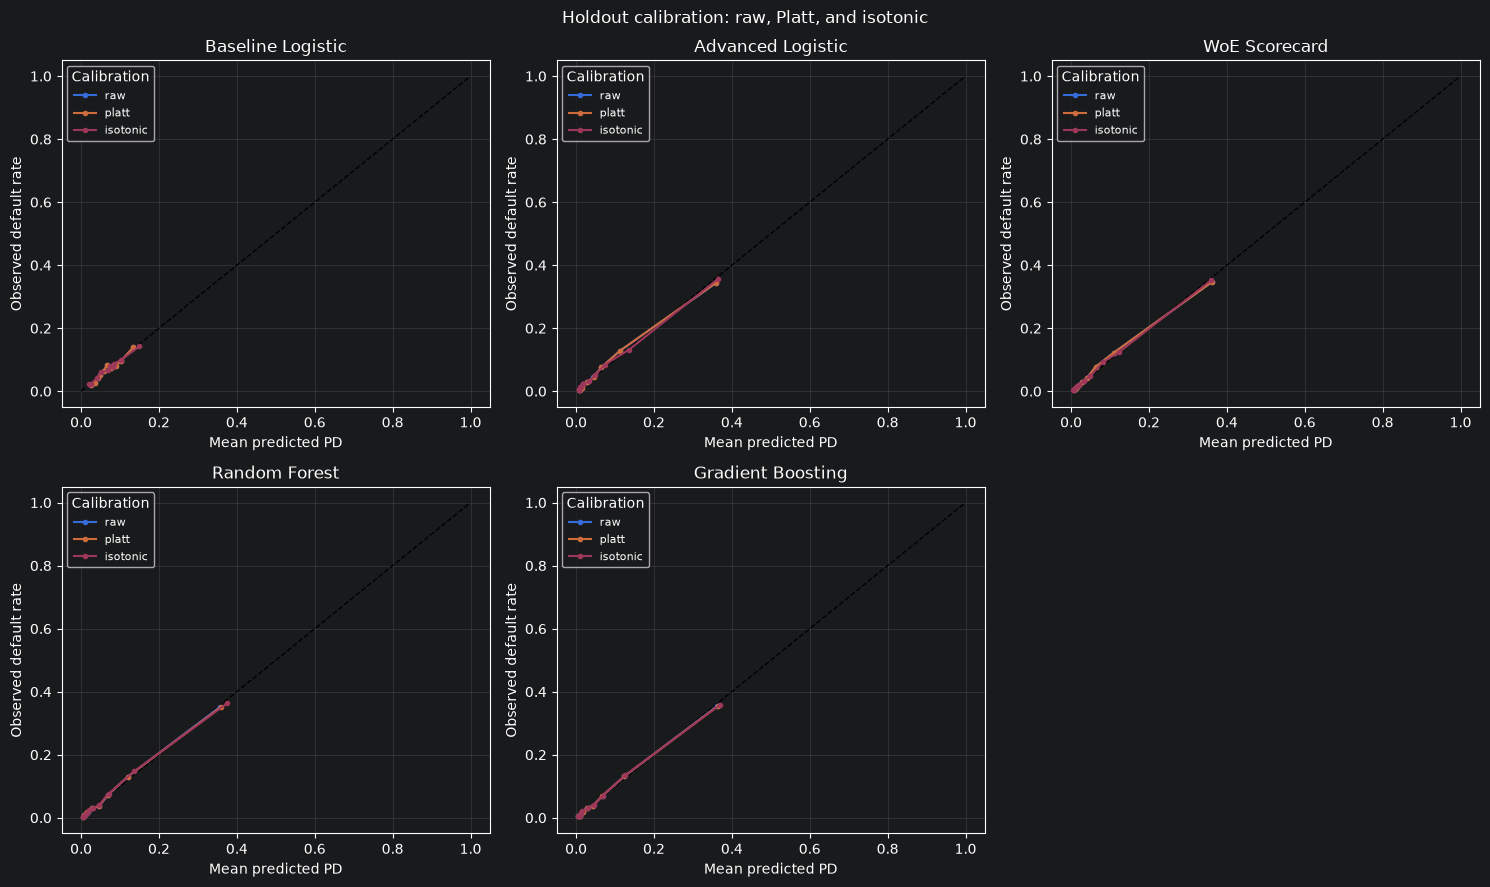

Saved calibration comparison to ../reports/figures/08_calibration_comparison.png


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, name in zip(axes.ravel(), MODEL_IDS):
    ax.plot([0, 1], [0, 1], color="black", linestyle="--", linewidth=1)
    for method in METHODS:
        tab = calibration_table(hold_y, cal_hold[name][method], bins=10)
        ax.plot(
            tab["mean_predicted_pd"], tab["actual_default_rate"],
            marker="o", markersize=3, label=method,
        )
    ax.set_title(label[name])
    ax.set_xlabel("Mean predicted PD")
    ax.set_ylabel("Observed default rate")
    ax.grid(alpha=0.2)
    ax.legend(title="Calibration", fontsize=8)
axes.ravel()[-1].axis("off")
fig.suptitle("Holdout calibration: raw, Platt, and isotonic")
fig.tight_layout()
FIG_PATH = "../reports/figures/08_calibration_comparison.png"
fig.savefig(FIG_PATH, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved calibration comparison to {FIG_PATH}")


## 6. Save the champion model

The final package contains the selected candidate and its training-fitted calibration mapping. It supports future PD predictions through the reusable prediction function in `src/model_comparison.py`.


In [11]:
model_obj = {
    "baseline": base_pack,
    "advanced": adv_pack,
    "scorecard": score_pack,
    "forest": forest_fit,
    "boost": boost_fit,
}[champ]
final_pack = {
    "model_id": champ,
    "model": model_obj,
    "cal": cal_fit[champ],
    "cal_method": cal_pick[champ],
    "seed": SEED,
    "features": list(feat.columns),
}
FINAL_PATH = "../models/final_model.pkl"
with open(FINAL_PATH, "wb") as model_file:
    pickle.dump(final_pack, model_file)
with open(FINAL_PATH, "rb") as model_file:
    loaded_pack = pickle.load(model_file)
loaded_pd = predict_candidate(hold_feat, loaded_pack)
reload_diff = float((loaded_pd - champ_pd).abs().max())
print(f"Saved champion model: {label[champ]}")
print(f"Saved calibration: {cal_pick[champ]}")
print(f"Maximum reloaded-PD difference: {reload_diff:.3g}")
print(f"Saved final package to {FINAL_PATH}")


Saved champion model: Gradient Boosting
Saved calibration: raw
Maximum reloaded-PD difference: 0
Saved final package to ../models/final_model.pkl


## Conclusion / Findings / Next step

The training-only selection rule chose Gradient Boosting. Its mean five-fold AUC was 0.8623, with mean Brier score 0.0499 and calibration gap 0.0031. Random Forest also passed the one-standard-error screens; Gradient Boosting had the lower mean calibration gap. The training-selected calibration method for the champion was raw probabilities.

On the seed 47 holdout, Gradient Boosting achieved AUC 0.8601 (95% bootstrap CI 0.8532 to 0.8658), Gini 0.7201, KS 0.5671, PR-AUC 0.3873, Brier score 0.0503, and calibration gap 0.0037. The paired 95% bootstrap interval for its AUC improvement over the calibrated baseline was 0.2007 to 0.2228. The holdout was used only for this final evaluation.

The selected model and calibration mapping are saved in `models/final_model.pkl`; its reloaded predictions match exactly. These results are conditional on one stratified split and do not replace temporal or external validation. Notebook 09 will demonstrate illustrative decisioning and monitoring methods.